# EV Car Prices

## Assignment 1 — Car Prices

The goal of this assignment is to predict car prices and compare different regression methods.

Methods used:
- Linear regression
- OLS 
- Ridge regression
- Lasso regression
- Elastic Net regression
- kNN classification

Main metrics used:
- MSE
- RMSE
- R²
- Accuracy for the kNN classification part


## Import data
 - Import the dataset 
 - Split the data in a training/ test set 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
car_prices = pd.read_excel("car_prices.xlsx")
labels = car_prices["Price (DKK)"]

X = car_prices.drop(columns=["Price (DKK)"])
y = labels

#split the data, 80% training 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X

,Model Year,Mileage (km),Electric Range (km),Battery Capacity (kWh),Energy Consumption (Wh/km),Annual Road Tax (DKK),Horsepower (bhp),0-100 km/h (s),Top Speed (km/h),Towing Capacity (kg),Original Price (DKK),Number of Doors,Rear-Wheel Drive,All-Wheel Drive (AWD),Front-Wheel Drive
0,2024,3000,270,39.0,168,780,147,7.9,144,1000,250720,5,0,0,1
1,2024,1001,536,82.0,177,780,408,4.9,180,1800,462900,5,0,1,0
2,2024,4000,460,64.8,162,780,204,7.8,167,750,345620,5,0,0,1
3,2024,10,550,76.6,153,780,286,6.7,180,1000,395615,5,1,0,0
4,2024,0,505,99.8,228,780,384,5.3,200,2500,745520,5,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6221,2023,12000,514,70.0,173,780,534,3.7,250,1600,452216,5,0,1,0
6222,2021,90000,469,78.0,193,780,408,4.7,210,1500,395420,5,0,1,0
6223,2023,11000,450,66.0,170,780,286,6.0,190,1600,475675,5,1,0,0
6224,2017,90000,280,28.0,115,780,120,9.9,165,1000,279994,5,0,0,1


## Part 1: Linear Algebra

In [2]:
# import numpy and add a bias term to the training data
import numpy as np
from sklearn.preprocessing import add_dummy_feature
X_train_b = add_dummy_feature(X_train)

# Calculate the normal equation for training data
theta_best_train = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
theta_best_train

array([-2.50479303e+10,  1.23667820e+07,  4.02527424e+02, -7.26113728e+04,
       -1.20249871e+03, -1.30106321e+05,  5.35702019e+04,  4.15407454e+04,
        1.62980674e+06, -4.18748917e+04, -3.55885631e+03,  8.15982894e+00,
        1.87218808e+06,  1.94994845e+07,  2.02668156e+07,  2.00772214e+07])

### Predict on the test data

In [3]:
#add bias column to test data and make predictions
X_test_b = add_dummy_feature(X_test) #add bias column
y_predict = X_test_b @ theta_best_train
y_predict_train = X_train_b @ theta_best_train
y_predict

array([  4636552.83097744,   6149851.03644267,    467142.4698688 , ...,
        14821836.23868243,    283244.10636376, -34037619.46275569],
      shape=(1246,))

### Calculating MSE using the formula

In [4]:
# MSE is the average squared difference between real and predicted prices.
# len is the number of values.
mse_test = np.sum((y_test  - y_predict)**2) / len(y_test)
mse_train = np.sum((y_train - y_predict_train)**2) / len(y_train)
print("Mse for training is: ",mse_train)
print("Mse for test is: ",mse_test)

Mse for training is:  119231263129689.9
Mse for test is:  139316419355561.05


### Calculating R^2

In [5]:
#R2 compares the model error with a simple baseline that predicts the mean.
R2_test = 1 - np.sum((y_test - y_predict)**2)/np.sum((y_test - np.mean(y_test))**2)
R2_train = 1 - np.sum((y_train - y_predict_train)**2)/np.sum((y_train - np.mean(y_train))**2)
print("R2 for training is: ",R2_train)
print("R2 for test is: ",R2_test)

R2 for training is:  -5378.831590338583
R2 for test is:  -6806.609594510798


### Interpreting values
#### R2 < 0
The test R² is negative, which means that this model performs worse than a simple baseline that predicts the mean price.
#### MSE
The MSE is also very high, so the model makes large prediction errors. 
This suggests that the simple linear algebra model does not fit the data well. 

# Part 2: Using Library Functions

### Correlation and OLS

In [6]:
# Check correlation between each feature and the target price.
corr_matrix = X_train.corrwith(y_train) 
print("Correlation with Price:")
print(corr_matrix)

Correlation with Price:
Model Year                    0.410882
Mileage (km)                 -0.205943
Electric Range (km)           0.523696
Battery Capacity (kWh)        0.604846
Energy Consumption (Wh/km)    0.591620
Annual Road Tax (DKK)         0.073145
Horsepower (bhp)              0.653520
0-100 km/h (s)               -0.538535
Top Speed (km/h)              0.569165
Towing Capacity (kg)          0.356561
Original Price (DKK)          0.897580
Number of Doors               0.144636
Rear-Wheel Drive              0.044100
All-Wheel Drive (AWD)         0.491236
Front-Wheel Drive            -0.475733
dtype: float64


### Visualisation of correlation_matrix with heatmap

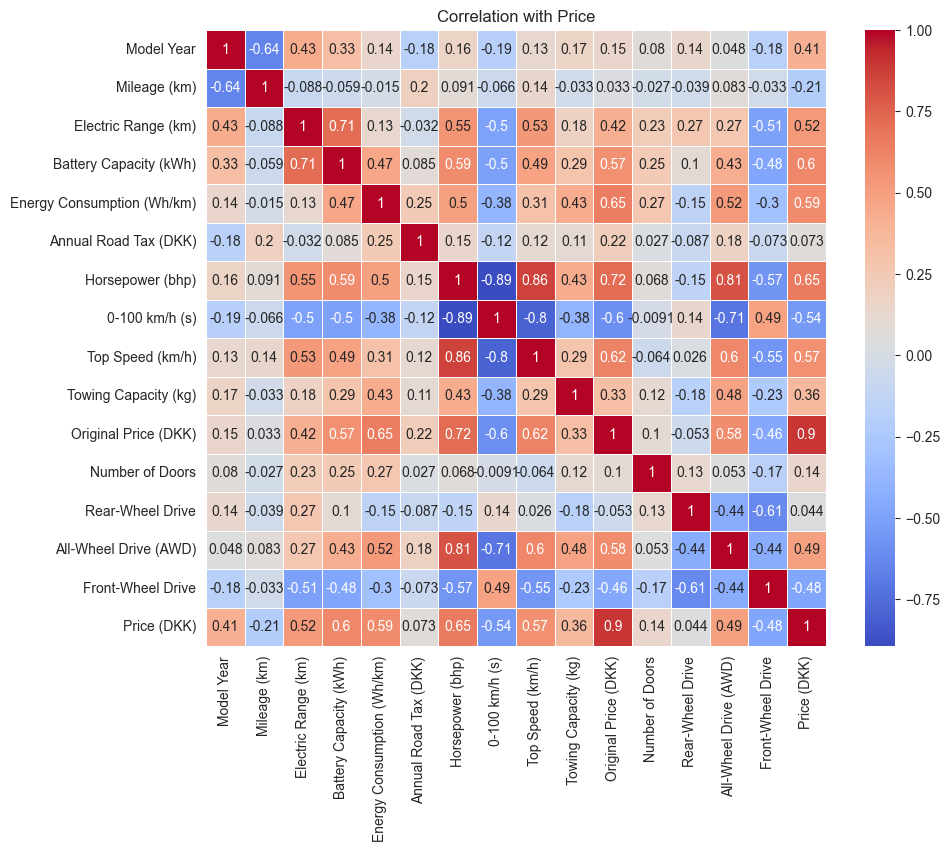

In [7]:
# Correlation matrix with heatmap
import seaborn as sns
data_with_target = X_train.copy()
data_with_target["Price (DKK)"] = y_train
# Calculate the correlation matrix including the target variable
correlation_matrix = data_with_target.corr()
plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=.5)
plt.title("Correlation with Price")
plt.show()

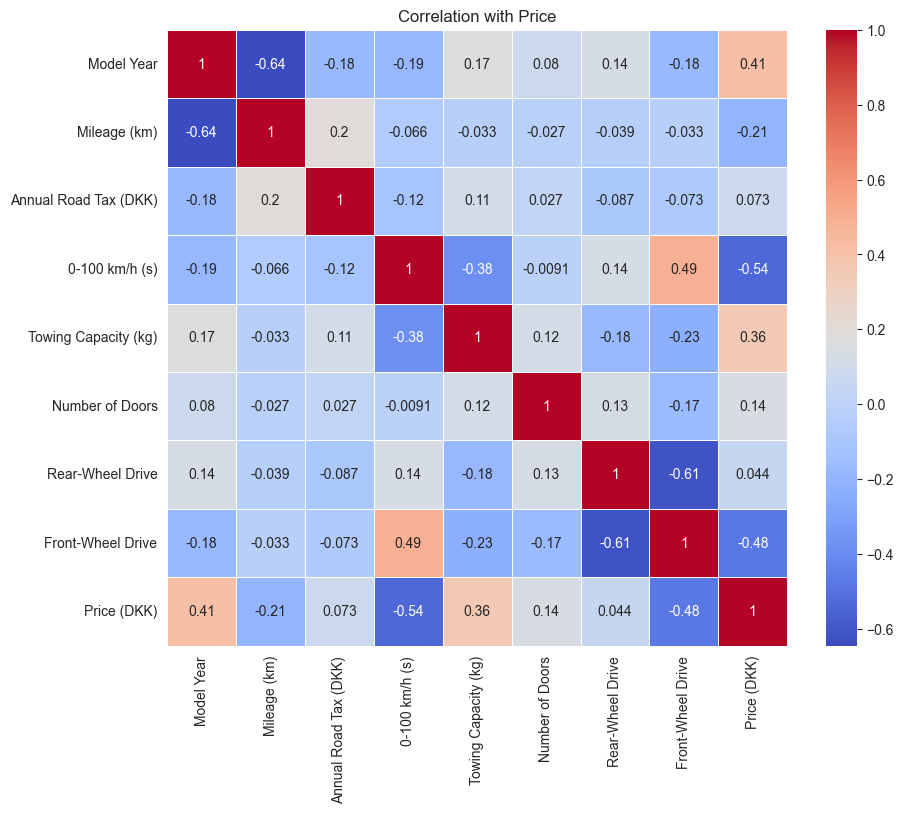

In [8]:
# Dropping high correlation columns
X_train = X_train.drop(columns=["Original Price (DKK)", "Top Speed (km/h)", "Horsepower (bhp)", "Battery Capacity (kWh)", "Electric Range (km)","Energy Consumption (Wh/km)","All-Wheel Drive (AWD)"])
X_test = X_test.drop(columns=["Original Price (DKK)", "Top Speed (km/h)", "Horsepower (bhp)", "Battery Capacity (kWh)", "Electric Range (km)","Energy Consumption (Wh/km)","All-Wheel Drive (AWD)"])

# Correlation matrix with heatmap
import seaborn as sns
data_with_target = X_train.copy()
data_with_target["Price (DKK)"] = y_train
# Calculate the correlation matrix including the target variable
correlation_matrix = data_with_target.corr()
plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=.5)
plt.title("Correlation with Price")
plt.show()

In [9]:
# Create and train regression model.
from sklearn.linear_model import LinearRegression
ols = LinearRegression()
ols.fit(X_train, y_train)

# Print the learned coefficients for each feature.
print("OLS =",ols.coef_)

mse_train = np.mean((y_train - ols.predict(X_train))**2)
mse_test = np.mean((y_test - ols.predict(X_test))**2)

# Calculate RMSE from the MSE values for both training and test sets.
RMSE_train = np.sqrt(mse_train)
RMSE_test = np.sqrt(mse_test)
print ("RMSE train =", RMSE_train)
print ("RMSE test =", RMSE_test)

OLS = [ 2.82542129e+04 -4.84734851e-01  2.89384499e+02 -1.90989642e+04
  3.04217798e+01  1.64182823e+04 -6.46247402e+04 -1.27871941e+05]
RMSE train = 107914.65398220475
RMSE test = 104197.32396675057


|in real world:
RMSE shows the typical prediction error in DKK

R² shows how much of the variation in car prices is explained by the model. A higher R² means the model explains more of the price variation.

### Ridge, Lasso and Elastic Net
I scale the features before Ridge, Lasso and Elastic Net because regularization depends on coefficient size. 

# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()


Note: You may get a convergence warning; try increasing the `max_iter` parameter of the model (the default is 1000 - maybe set it to 100000)

In [10]:
from sklearn.preprocessing import StandardScaler
# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()

# Convert y to a NumPy array before reshaping it for the scaler.
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

### Ridge regression
# impact of alpha hyperparameter on Ridge regression

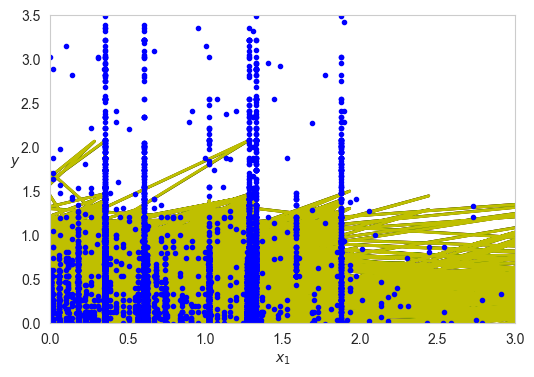

In [11]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Calculate the denominator for R2 once, because y_test_scaled does not change.
# This is the total variance in the test target values.
bottom_sum_scaled = np.sum((y_test_scaled - np.mean(y_test_scaled))**2)

# Start with a very high MSE for Ridge regression to find the best alpha.
min_mse_ridge = 999999

# Store the R2-related value for the best Ridge model.
for_min_mse_R2_ridge = 2
plt.figure(figsize=(6, 4))

# Test different alpha values
# Alpha controls the strength of regularization in Ridge regression. Higher alpha means more regularization.
for alpha, style in ((0.1, "r-"), (1, "g-"), (10, "y-")):
    ridge_reg = Ridge(alpha=alpha)
    ridge_reg.fit(X_train_scaled, y_train_scaled)
    y_ridge = ridge_reg.predict(X_test_scaled)
    mse_ridge = np.mean((y_test_scaled - y_ridge)**2)
    if (min_mse_ridge > mse_ridge):
        best_ridge_coef = ridge_reg.coef_
        best_alpha_ridge = alpha
        min_mse_ridge = mse_ridge
        for_min_mse_R2_ridge = (
                np.sum((y_test_scaled - y_ridge)**2)/
                bottom_sum_scaled)

    label_ridge = f"Ridge alpha={alpha}"
    plt.plot(X_test_scaled, y_ridge, style, label=label_ridge, linewidth=2)

plt.plot(X_train_scaled, y_train_scaled, "b.", linewidth=3)
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [12]:
print("With best alpha", best_alpha_ridge)
print("MSE" , mse_ridge)
print("R2" , for_min_mse_R2_ridge)

With best alpha 10
MSE 0.489735048993238
R2 0.5303651612463448


### Lasso regression
# impact of alpha hyperparameter on Lasso regression

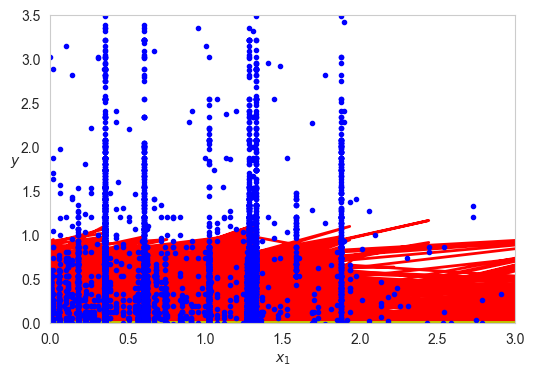

In [13]:
# Start with a very high MSE for Lasso regression to find the best alpha.
min_mse_lasso = 999999

# Store the R2-related value for the best Lasso model.
for_min_mse_R2_lasso = 2
plt.figure(figsize=(6, 4))

# Test different alpha values.
# Alpha controls the strength of L1 regularization. Higher alpha means more regularization, which can lead to more coefficients being set to zero.
for alpha, style in ((0.1, "r-"), (1, "g-"), (10, "y-")):
    lasso_reg = Lasso(alpha=alpha)
    lasso_reg.fit(X_train_scaled, y_train_scaled)
    y_lasso = lasso_reg.predict(X_test_scaled)
    mse_lasso = np.mean((y_test_scaled - y_lasso)**2)
    if(min_mse_lasso > mse_lasso):
        best_lasso_coef = lasso_reg.coef_
        best_alpha_lasso = alpha
        min_mse_lasso = mse_lasso
        for_min_mse_R2_lasso = (
                np.sum((y_test_scaled - y_lasso)**2)/
                bottom_sum_scaled)
    label_lasso = f"Lasso alpha={alpha}"
    plt.plot(X_test_scaled, y_lasso, style, label=label_lasso, linewidth=2)

plt.plot(X_train_scaled, y_train_scaled, "b.", linewidth=3)
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [14]:
print("With best alpha", best_alpha_lasso)
print ("MSE" , min_mse_lasso)
print("R2" , for_min_mse_R2_lasso)

With best alpha 0.1
MSE 0.5219311474610362
R2 0.565232359316975


### Elastic Net regression
# Elastic Net combines Ridge and Lasso.
# The l1_ratio controls the balance between L1 and L2 regularization.

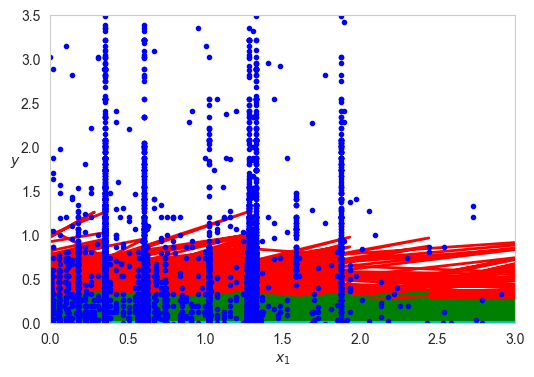

In [15]:
# Start with a very high MSE so the first tested model becomes the first best model.
min_mse_net = 999999
for_min_mse_R2_net = 2
plt.figure(figsize=(6, 4))

# Test different l1_ratio values.
# l1_ratio = 0 is close to Ridge behaviour.
# l1_ratio = 1 is close to Lasso behaviour.
# Values between 0 and 1 combine both penalties.
for l1_ratio, style in ((0, "r-"), (0.3, "g-"), (1, "c-")):
    elastic_net_reg = ElasticNet(alpha=1, l1_ratio=l1_ratio, max_iter=100000)
    elastic_net_reg.fit(X_train_scaled, y_train_scaled)
    y_elastic_net = elastic_net_reg.predict(X_test_scaled)
    mse_elastic_net = np.mean((y_test_scaled - y_elastic_net)**2)
    
    # select the best case
    if(min_mse_net > mse_elastic_net):
        best_ratio_net = l1_ratio
        min_mse_net = mse_elastic_net
        for_min_mse_R2_net = (
                np.sum((y_test_scaled - y_elastic_net)**2)/
                bottom_sum_scaled)
    label_elastic_net = f"Elastic Net alpha={1} l1_ratio={l1_ratio}"
    plt.plot(X_test_scaled, y_elastic_net, style, label=label_elastic_net, linewidth=2)

plt.plot(X_train_scaled, y_train_scaled, "b.", linewidth=3)
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [16]:
print ("With elastic net ratio" , best_ratio_net)
print ("MSE" , min_mse_net)
print("R2" , for_min_mse_R2_net)

With elastic net ratio 0
MSE 0.5353740917669134
R2 0.5797905767430482


## Observation
After finding the most efficient alpha in the options given, it seems that even with a higher MSE the R2 of Elastic Net is the best at predicting.
Ols on scared data has much lower values than ols with unscaled data resulting in much higher accuracy seen in the MSE and R2 of the regresion models.

In [17]:
# Train an OLS model on the scaled data so its coefficients can be compared
# with Ridge and Lasso coefficients.
ols_scaled = LinearRegression()
ols_scaled.fit(X_train_scaled, y_train_scaled)
ridge_coefficients = best_ridge_coef
lasso_coefficients = best_lasso_coef
ols_coefficients = ols_scaled.coef_
feature_names = X.columns

# Sort coefficients by absolute value.
# A larger absolute coefficient means the feature has a stronger effect in the model.
ridge_sorted_idx = np.argsort(np.abs(ridge_coefficients))[::-1]
lasso_sorted_idx = np.argsort(np.abs(lasso_coefficients))[::-1]
ols_sorted_idx = np.argsort(np.abs(ols_coefficients))[::-1]

# Get the top 5 most important features for each model based on the absolute value of their coefficients.
top_5_ridge_features = feature_names[ridge_sorted_idx][:5]
top_5_lasso_features = feature_names[lasso_sorted_idx][:5]
top_5_ols_features = feature_names[ols_sorted_idx][:5]

print("Top 5 Features from Ridge Model:")
for i, feature in enumerate(top_5_ridge_features, 1):
    print(f"{i}. {feature} (Coefficient: {ridge_coefficients[ridge_sorted_idx[i-1]]})")

print("\nTop 5 Features from Lasso Model:")
for i, feature in enumerate(top_5_lasso_features, 1):
    print(f"{i}. {feature} (Coefficient: {lasso_coefficients[lasso_sorted_idx[i-1]]})")

print("\nTop 5 Features from OLS Model:")
for i, feature in enumerate(top_5_ols_features, 1):
    print(f"{i}. {feature} (Coefficient: {ols_coefficients[ols_sorted_idx[i-1]]})")

Top 5 Features from Ridge Model:
1. 0-100 km/h (s) (Coefficient: -0.4138957713062628)
2. Model Year (Coefficient: 0.26161947243140227)
3. Battery Capacity (kWh) (Coefficient: -0.22840158146052808)
4. Horsepower (bhp) (Coefficient: -0.20759422984341486)
5. Mileage (km) (Coefficient: -0.08030229814126114)

Top 5 Features from Lasso Model:
1. Battery Capacity (kWh) (Coefficient: -0.282459751056235)
2. Model Year (Coefficient: 0.21284430925153836)
3. 0-100 km/h (s) (Coefficient: -0.18302545934626796)
4. Energy Consumption (Wh/km) (Coefficient: 0.06872533358369336)
5. Annual Road Tax (DKK) (Coefficient: 0.0)

Top 5 Features from OLS Model:
1. 0-100 km/h (s) (Coefficient: -0.4172833771732275)
2. Model Year (Coefficient: 0.2625301931913246)
3. Battery Capacity (kWh) (Coefficient: -0.2268986960117888)
4. Horsepower (bhp) (Coefficient: -0.21054490654079813)
5. Mileage (km) (Coefficient: -0.08002564586674465)


#We can see that all models consider Model Year as the most important coefficient 0-100 km/h being the second most important but afterwards the models disagree with the importance of some features

## Part 3: Classification

### kNN Classifier
I convert the regression target into a binary classification target: cheap or expensive.

In [18]:
# Create a binary target: 1 - expensive, 0 - cheap.
from sklearn.neighbors import KNeighborsClassifier
middle_price = y.median()
cheap_expensive = (y > middle_price).astype(int)
cheap_expensive.name = "Cheap/Expensive"
cheap_expensive_train, cheap_expensive_test = train_test_split(cheap_expensive, test_size=0.2, random_state=42)
cheap_expensive_test

239     1
1119    1
2215    1
2500    1
5783    1
       ..
3002    0
1025    0
1614    0
5153    1
3819    0
Name: Cheap/Expensive, Length: 1246, dtype: int64

In [19]:
model = KNeighborsClassifier()
X_train_scaled_df = X_train_scaled.copy()
X_test_scaled_df = X_test_scaled.copy()

# Fit the default kNN model on the scaled training data.
model.fit(X_train_scaled_df, cheap_expensive_train) 
y_predict_knn = model.predict(X_test_scaled_df)
print("Prediction: {}".format(y_predict_knn))
print("Accuracy score test: {}".format(model.score(X_test_scaled_df, cheap_expensive_test)))
print("Accuracy score train: {}".format(model.score(X_train_scaled_df, cheap_expensive_train)))

Prediction: [1 1 1 ... 0 1 0]
Accuracy score test: 0.8956661316211878
Accuracy score train: 0.9373493975903614


In [20]:
from sklearn.metrics import accuracy_score
neighbors_range = range(3, 20)  # Number of neighbors from 3 to 19
distance_metrics = ['euclidean', 'manhattan', 'minkowski']  # Distance metrics tested for kNN

# Variables to store the best parameters and highest accuracy
best_accuracy = 0
best_params = {'n_neighbors': None, 'metric': None}

# Nested loop to iterate over the hyperparameters
for n_neighbors in neighbors_range:
    for metric in distance_metrics:
        # Initialize the KNN model with current hyperparameters
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)

        # Train the model
        knn.fit(X_train_scaled_df, cheap_expensive_train)

        # Make predictions on the test set
        predictions = knn.predict(X_test_scaled_df)

        # Calculate the accuracy
        accuracy = accuracy_score(cheap_expensive_test, predictions)
        # To better look at the difference depending on each hyperparameter
        print(f"Current n_neighbors - {n_neighbors}, Metric - {metric}")
        print(f"Accuracy: {accuracy*100:.2f}%")
        
        # Update the best parameters if current accuracy is higher
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params['n_neighbors'] = n_neighbors
            best_params['metric'] = metric

Current n_neighbors - 3, Metric - euclidean
Accuracy: 90.61%
Current n_neighbors - 3, Metric - manhattan
Accuracy: 90.77%
Current n_neighbors - 3, Metric - minkowski
Accuracy: 90.61%
Current n_neighbors - 4, Metric - euclidean
Accuracy: 89.89%
Current n_neighbors - 4, Metric - manhattan
Accuracy: 90.69%
Current n_neighbors - 4, Metric - minkowski
Accuracy: 89.89%
Current n_neighbors - 5, Metric - euclidean
Accuracy: 89.57%
Current n_neighbors - 5, Metric - manhattan
Accuracy: 90.29%
Current n_neighbors - 5, Metric - minkowski
Accuracy: 89.57%
Current n_neighbors - 6, Metric - euclidean
Accuracy: 89.73%
Current n_neighbors - 6, Metric - manhattan
Accuracy: 90.21%
Current n_neighbors - 6, Metric - minkowski
Accuracy: 89.73%
Current n_neighbors - 7, Metric - euclidean
Accuracy: 90.53%
Current n_neighbors - 7, Metric - manhattan
Accuracy: 90.93%
Current n_neighbors - 7, Metric - minkowski
Accuracy: 90.53%
Current n_neighbors - 8, Metric - euclidean
Accuracy: 90.61%
Current n_neighbors - 8,

In [21]:
# Print the best set of parameters and the highest accuracy achieved
print(f"Best parameters: Number of Neighbors - {best_params['n_neighbors']}, Distance Metric - {best_params['metric']}")
print(f"Highest Accuracy: {best_accuracy*100:.2f}%")

Best parameters: Number of Neighbors - 10, Distance Metric - manhattan
Highest Accuracy: 91.09%


### Observation

The value of k controls how local or general the kNN decision rule is:
- very small k can make the model too sensitive to individual training points, which can lead to overfitting. 
- very large k can make the decision boundary too simple, which can lead to underfitting.

I tested different k values and distance metrics, then selected the combination with the highest test accuracy.

## Final conclusion

This assignment focused mainly on regression for predicting car prices, and then on kNN classification for classifying cars as cheap or expensive.

The first linear regression model used the normal equation to calculate coefficients directly. Its weak result, especially the negative R², suggests that the simple linear model did not capture the price relationship well enough.

I then compared library-based linear regression and regularized models: Ridge, Lasso and Elastic Net. Regularization is useful because it penalizes large coefficients and can improve generalization.

For the classification part, I used kNN. Since kNN is based on distances, scaling was important. I tested different values of k and different distance metrics to find the best-performing combination.

One limitation is that car prices can depend on complex non-linear factors, so simple linear models may not capture all patterns in the data. A possible improvement would be to try non-linear models or more feature engineering.